# Introduction to Data Science – Homework 6
*COMP 5360 / MATH 4100, University of Utah, http://datasciencecourse.net/*

Due: Friday, Feburary 28 2025, 11:59pm.

In Part 1 of this homework you will scrape github repositories and organize the information in a Pandas dataframe. In Part 2, you will use linear regression to gain meaningful insights. 

## Your Data
First Name: Lindsey Kwon
<br>
Last Name:
<br>
E-mail:
<br>
UID: u0895615
<br>

In [9]:
# imports and setup 
from bs4 import BeautifulSoup

import pandas as pd
import scipy as sc
import numpy as np

import statsmodels.formula.api as sm

import matplotlib.pyplot as plt 
plt.style.use('ggplot')
%matplotlib inline  
plt.rcParams['figure.figsize'] = (10, 6) 
# where the data is stored
DATA_PATH = "snapshots"

### 1. Scrape Github Repository List using BeautifulSoup
In this part you will explore Github repositories, specifically the 100 most-starred repositories. You are going to scrape data from a snapshot of [this repository list](https://github.com/search?o=desc&q=stars%3A%3E1&s=stars&type=Repositories).

### 1.1. Check whether you are permitted to scrape the data
Before you start to scrape any website you should go through the terms of service and policy documents of the website. Almost all websites post conditions to use their data. Check the terms of [https://github.com/](https://github.com/) (see the tiny "terms" link at the bottom of the page) to see whether the site permits you to scrape their data or not. Are you sure you are allowed to scrape?

**Your solution:**
TODO

yes

Reference solution: The [terms of service](https://help.github.com/articles/github-terms-of-service/) do not mention scraping, but the [help pages on the site policy](https://help.github.com/en/github/site-policy/github-acceptable-use-policies#5-scraping-and-api-usage-restrictionsyou) allows scraping. You can scrape Github under the following conditions:

- Researchers may scrape public, non-personal information from GitHub for research purposes, only if any publications resulting from that research are open access.
- Archivists may scrape GitHub for public data for archival purposes.
- You may not scrape GitHub for spamming purposes, including for the purposes of selling GitHub users' personal information, such as to recruiters, headhunters, and job boards.

The [robots.txt](https://github.com/robots.txt) is a little less explicit about what is allowed and what not, but overall, since we are scraping Github pages for education/research purposes and not publishing the results, it is reasonable to assume that this is ok to do.

### Task 1.2 Load the Data

To avoid any problems with GitHub blocking us from downloading the data many times, we have downloaded and saved a snapshot of the html files for you in the [snapshots](snapshots) folder. Note that the snapshots folder is not completely consistent with what you see on the web – we've made a few patches to the data that makes your task here easier and this data represents a snapshot in time. You will be treating the data folder as your website to be scraped. The path to data folder is stored in `DATA_PATH` variable.

In the data folder you will find first 10 pages of highly starred repositories saved as `search_page_1.html`,`search_page_2.html`,`search_page_3.html` ... `search_page_10.html`

Check out page 5 if you want to see what happens if you scrape too quickly 😉. **Tip**: you should skip page 5.

Now read these html files in python and create a soup object. This is a two step process:
 * Read the text in the html files
 * Create the soup from the files that you've read. 

In [10]:
## Your code goes here

import os

os.listdir("snapshots")


['521xueweihan',
 '996icu',
 'angular',
 'animate-css',
 'ant-design',
 'awesome-selfhosted',
 'base',
 'binary-husky',
 'bitcoin',
 'Chalarangelo',
 'ChatGPTNextWeb',
 'codecrafters-io',
 'coder',
 'comfyanonymous',
 'CompVis',
 'CyC2018',
 'd3',
 'deepseek-ai',
 'Developer-Y',
 'donnemartin',
 'EbookFoundation',
 'electron',
 'enaqx',
 'excalidraw',
 'expressjs',
 'f',
 'facebook',
 'facebook_react-native',
 'florinpop17',
 'freeCodeCamp',
 'Genymobile',
 'getify',
 'godotengine',
 'golang',
 'gothinkster',
 'grafana',
 'hakimel',
 'jaywcjlove',
 'justjavac',
 'jwasham',
 'kamranahmedse',
 'krahets',
 'kubernetes',
 'labuladong',
 'langchain-ai',
 'macrozheng',
 'massgravel',
 'microsoft',
 'microsoft_terminal',
 'microsoft_Web-Dev-For-Beginners',
 'moby',
 'mtdvio',
 'mui',
 'neovim',
 'nestjs',
 'ohmyzsh',
 'ollama',
 'opencv',
 'ossu',
 'pallets',
 'practical-tutorials',
 'public-apis',
 'python',
 'rustdesk',
 'ryanmcdermott',
 'sdmg15',
 'search_page_1.html',
 'search_page_10.ht

In [11]:
# Creating the soup
## Your code goes here

from bs4 import BeautifulSoup

# example: open one file
with open("snapshots/search_page_1.html", "r", encoding="utf-8") as f:
    html = f.read()

soup = BeautifulSoup(html, "html.parser")

print(soup.title)

<title>Repository search results</title>


In [12]:
soup

<!DOCTYPE html>

<!-- saved from url=(0077)https://github.com/search?o=desc&q=stars%3A%3E1&s=stars&type=Repositories&p=1 -->
<html data-a11y-animated-images="system" data-a11y-link-underlines="true" data-color-mode="auto" data-dark-theme="dark" data-light-theme="light" data-turbo-loaded="" lang="en"><head><meta content="text/html; charset=utf-8" http-equiv="Content-Type"/><style type="text/css">.turbo-progress-bar {
  position: fixed;
  display: block;
  top: 0;
  left: 0;
  height: 3px;
  background: #0076ff;
  z-index: 2147483647;
  transition:
    width 300ms ease-out,
    opacity 150ms 150ms ease-in;
  transform: translate3d(0, 0, 0);
}
</style>
<link href="https://github.githubassets.com/" rel="dns-prefetch"/>
<link href="https://avatars.githubusercontent.com/" rel="dns-prefetch"/>
<link href="https://github-cloud.s3.amazonaws.com/" rel="dns-prefetch"/>
<link href="https://user-images.githubusercontent.com/" rel="dns-prefetch"/>
<link crossorigin="" href="https://github.githubasse

### Extracting Data

Extract the following data for each repository, and create a Pandas Dataframe with a row for each repository and a column for each of these datums. 

+ The name of the repository
+ The primary language (there are multiple or none, if multiple, use the first one, if none, use "none")
+ The number of watching
+ The number of stars
+ The number of forks
+ The number of issues
+ Number of commits
+ Number of pull requests, and

Here's an example for one repository, `freeCodeCamp/freeCodeCamp,` in our dataset: 
```python
{'name': 'freeCodeCamp',
'language': 'TypeScript',
'watching': '8500',
'stars': '410251',
'forks': '39007',
'issues': 168,
'commits': 37591,
'pull_requests':66
}
```
### Task 1.3 Extract repository URLs

If you look at the results of the 100 most-starred repositories [(this list)](https://github.com/search?o=desc&q=stars%3A%3E1&s=stars&type=Repositories), you will notice that all the information we want to extract for each repository is not in that list. This information is in the repository’s individual web page, for example [996icu](https://github.com/996icu/996.ICU). 

Therefore, you will first have to extract links of each repository from the soup you scraped earlier. When you extract the link for the repository, it will be a path to the stored HTML page for the repository. You will use this path to read the file and extract the above information.

Refer to the scraping lecture for details on how to do this. We recommend you use the web inspector to identify the relevant structures.

Example of a link that you need to extract - `996icu/996.ICU.html`. This means in the next task you need to access local folder `snapshots/996icu/996.ICU.html`. Similarly, for `521xueweihan/HelloGitHub.html` you should access `snapshots/521xueweihan/HelloGitHub.html` 

You may need to do string operations to get the desired format for the link. For example, if you get `raw_link = https://github.com/996icu/996.ICU`, you can do
`link = raw_link.replace("https://github.com/", "") + ".html"` so you get `996icu/996.ICU.html`.
Please title your output 'repo_list', and print this list once you have created it.

In [13]:
## Your code goes here

import os
print(os.getcwd())

import os
from bs4 import BeautifulSoup

repo_list = []

#skip page 5
pages = [1,2,3,4,6,7,8,9,10]

for page_num in pages:
    
    file_path = "snapshots/search_page_" + str(page_num) + ".html"
    
    #read html file
    f = open(file_path, "r", encoding="utf-8")
    html = f.read()
    f.close()
    
    #make soup
    soup = BeautifulSoup(html, "html.parser")
    
    #find all links
    links = soup.find_all("a")
    
    for a in links:
        href = a.get("href")
        
        if href is None:
            continue
        
        
        if "https://github.com/" not in href:
            continue
        
        
        href = href.split("?")[0]
        href = href.split("#")[0]
        
        #remove the main part
        href = href.replace("https://github.com/", "")
        

        if href.endswith("/"):
            href = href[:-1]
        
        parts = href.split("/")
        
        #repo links should look like: owner/repo
        if len(parts) != 2:
            continue
        
        owner = parts[0]
        repo = parts[1]
        
        #skip nonrepo paths-not owners
        bad_first_words = ["topics", "collections", "sponsors", "about", "site", "contact", "orgs", "search", "pricing", "login", "signup"]
        if owner in bad_first_words:
            continue
        
        #local html file path format
        repo_file = owner + "/" + repo + ".html"
        
        if repo_file not in repo_list:
            repo_list.append(repo_file)

#repo_list
print("Number of repositories:", len(repo_list))
print(repo_list[:20])

c:\Users\abbyc\OneDrive\Documents\GitHub\2026-datascience-homework\HW6
Number of repositories: 91
['freeCodeCamp/freeCodeCamp.html', 'EbookFoundation/free-programming-books.html', 'sindresorhus/awesome.html', 'codecrafters-io/build-your-own-x.html', 'public-apis/public-apis.html', 'jwasham/coding-interview-university.html', 'kamranahmedse/developer-roadmap.html', 'donnemartin/system-design-primer.html', '996icu/996.ICU.html', 'vinta/awesome-python.html', 'facebook/react.html', 'practical-tutorials/project-based-learning.html', 'awesome-selfhosted/awesome-selfhosted.html', 'vuejs/vue.html', 'vuejs/core.html', 'TheAlgorithms/Python.html', 'trekhleb/javascript-algorithms.html', 'tensorflow/tensorflow.html', 'torvalds/linux.html', 'getify/You-Dont-Know-JS.html']


### Task 1.4 Extracting required information

Once you have extracted links for each repository, you can start parsing those HTML pages using BeautifulSoup and extract all the required information.

**Note**: There are few repositories which do not contain 'issues' field (such as 996icu/996.ICU.html). Therefore, write your code such that it handles this condition as well.

**Save the dataframe you created to a new file project_info.csv and include this in your submission.** This separate file will also be graded and is required to earn points.

You also need to make sure that you reformat all numerical columns to be integer data. You can do that either as you parse, or when you have a dataframe with strings.

Some repositories (~30) are missing in the collection, we have provided code to skip these cases, and similarly in the next frame to NOT include the None numbers in the storage.

**Tips**: the exact value of stars and forks can be found on top right corner, with mouse hover over the value. E.g., hover over 410k, shows 410,246. For *watching*, the data is abbreviated, You need to manually convert it. For example, 8.5k should be converted to 8500.

#### from pathlib import Path

def extract_repository_details(url):
    row = []
    
    file_path = Path("snapshots") / url
    if file_path.exists():
        with file_path.open('r', encoding="utf8") as f:
            file = f.read()
            
    ## Your code goes here
    
    data = {"name": repo_name,
            "language":language,
            "watching": watching, 
            "stars": stars, 
            "forks": forks, 
            "issues":issues,
            "commits": commits,
            "pull_requests": pull_requests
    }
        
    return(data)

In [14]:
from pathlib import Path
from bs4 import BeautifulSoup
import re


def clean_number(text):
    if text is None or not text.strip():
        return None
    text = text.replace(',', '').strip()
    if 'k' in text.lower():
        return int(float(text.lower().replace('k', '')) * 1000)
    if 'm' in text.lower():
        return int(float(text.lower().replace('m', '')) * 1000000)
    try:
        return int(text)
    except:
        return None



def extract_repository_details(url):
    file = Path("snapshots") / url
    
    if not file.exists():
        print("no file:", url)
        return None
    
    html = file.read_text(encoding="utf-8")
    soup = BeautifulSoup(html, "html.parser")
    
    #name
    name = "none"
    name_tag = soup.find("strong", {"itemprop": "name"})
    if name_tag:
        name = name_tag.get_text().strip()
    
    #language
    lang = "none"
    lang_tag = soup.find("span", {"itemprop": "programmingLanguage"})
    if lang_tag:
        lang = lang_tag.get_text().strip()
    
    #start with none
    watch = stars = forks = issues = commits = pulls = None
    
    #all the numbers
    all_text = soup.get_text()
    numbers = re.findall(r'\d{1,3}(?:,\d{3})*', all_text)
    
    big = []
    for n in numbers:
        try:
            num = int(n.replace(',', ''))
            if num > 1000:  
                big.append(num)
        except:
            pass
    
    #big numbers bigger than 3
    if len(big) >= 3:
        watch = big[0]   
        stars = max(big) 
        
        big.sort(reverse=True)
        forks = big[1]
    
    #issue pull commit
    small = [n for n in big if n < 10000]
    if len(small) >= 3:
        issues = small[0]
        pulls = small[1]
        commits = small[2]
    
    #result
    print("file:", url)
    print("name:", name)
    print("language:", lang)
    print("watching:", watch)
    print("star:", stars)
    print("fork:", forks)
    print("issue:", issues)
    print("commit:", commits)
    print("pullrequest:", pulls)
    print("---")
    
    #data
    data = {
        "name": name,
        "language": lang,
        "watching": watch,
        "stars": stars,
        "forks": forks,
        "issues": issues,
        "commits": commits,
        "pull_requests": pulls
    }
    
    return data



print("test")
test_file = "freeCodeCamp/freeCodeCamp.html"  
result = extract_repository_details(test_file)

if result:
    print("\n결result")
    print(result)
else:
    print("nothing")

project_info = pd.DataFrame([result])  
project_info.to_csv("project_info.csv", index=False)
print("csv saved, open")

repo_info_list = []
for repo in repo_list:
    item = extract_repository_details(repo)
    if item:
        repo_info_list.append(item)

project_info = pd.DataFrame(repo_info_list)
project_info.to_csv("project_info.csv", index=False)

print("finished")
print(project_info.head(10))

test
file: freeCodeCamp/freeCodeCamp.html
name: freeCodeCamp
language: none
watching: 37591
star: 40000
fork: 37591
issue: 5313
commit: 1800
pullrequest: 5000
---

결result
{'name': 'freeCodeCamp', 'language': 'none', 'watching': 37591, 'stars': 40000, 'forks': 37591, 'issues': 5313, 'commits': 1800, 'pull_requests': 5000}
csv saved, open
file: freeCodeCamp/freeCodeCamp.html
name: freeCodeCamp
language: none
watching: 37591
star: 40000
fork: 37591
issue: 5313
commit: 1800
pullrequest: 5000
---
file: EbookFoundation/free-programming-books.html
name: free-programming-books
language: none
watching: 9499
star: 9499
fork: 2989
issue: 9499
commit: 2975
pullrequest: 2989
---
file: sindresorhus/awesome.html
name: awesome
language: none
watching: None
star: None
fork: None
issue: None
commit: None
pullrequest: None
---
file: codecrafters-io/build-your-own-x.html
name: build-your-own-x
language: none
watching: None
star: None
fork: None
issue: None
commit: None
pullrequest: None
---
file: public-

In [15]:
print(project_info.head(10))

                          name language  watching         stars         forks  \
0                 freeCodeCamp     none   37591.0  4.000000e+04  3.759100e+04   
1       free-programming-books     none    9499.0  9.499000e+03  2.989000e+03   
2                      awesome     none       NaN           NaN           NaN   
3             build-your-own-x     none       NaN           NaN           NaN   
4                  material-ui     none   26364.0  1.407391e+06  2.636400e+04   
5  coding-interview-university     none       NaN           NaN           NaN   
6            developer-roadmap     none    6243.0  6.243000e+03  1.245000e+03   
7         system-design-primer     none   65536.0  1.099512e+12  4.294967e+09   
8                      996.ICU     none       NaN           NaN           NaN   
9               awesome-python     none       NaN           NaN           NaN   

   issues  commits  pull_requests  
0  5313.0   1800.0         5000.0  
1  9499.0   2975.0         2989.0  


### 2. Analyzing the repository data

In this part, you will analyze the data collected in Part 1 using regression tools. The goal is to identify properties that make a repository popular. 

First, load the `project_info.csv` file in again. **We need you to do this so that we can run your code below without having to run your scraping code, which can be slow.**

In [16]:
project_info = pd.read_csv('project_info.csv')
project_info.head()

,name,language,watching,stars,forks,issues,commits,pull_requests
0,freeCodeCamp,none,37591.0,40000.0,37591.0,5313.0,1800.0,5000.0
1,free-programming-books,none,9499.0,9499.0,2989.0,9499.0,2975.0,2989.0
2,awesome,none,NaN,NaN,NaN,NaN,NaN,NaN
3,build-your-own-x,none,NaN,NaN,NaN,NaN,NaN,NaN
4,material-ui,none,26364.0,1407391.0,26364.0,3009.0,1500.0,2995.0


### Task 2.1.1 Describe the data

+ Get an overview of the data using the describe function.
+ Compute the correlation matrix, visualize it with a labeled heat map.
+ Interpret what you see, and discuss why some variables may or may not be correlated with others.

You can re-use code from your previous homework here.

In [17]:
# your code goes here - describe

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


project_info = pd.read_csv('project_info.csv')

print("first 5 rows:")
print(project_info.head())

#summary 
print("\ndata summary (describe):")
print(project_info.describe())

first 5 rows:
                     name language  watching      stars    forks  issues  \
0            freeCodeCamp     none   37591.0    40000.0  37591.0  5313.0   
1  free-programming-books     none    9499.0     9499.0   2989.0  9499.0   
2                 awesome     none       NaN        NaN      NaN     NaN   
3        build-your-own-x     none       NaN        NaN      NaN     NaN   
4             material-ui     none   26364.0  1407391.0  26364.0  3009.0   

   commits  pull_requests  
0   1800.0         5000.0  
1   2975.0         2989.0  
2      NaN            NaN  
3      NaN            NaN  
4   1500.0         2995.0  

data summary (describe):
           watching         stars         forks       issues      commits  \
count  2.100000e+01  2.100000e+01  2.100000e+01    11.000000    11.000000   
mean   9.201395e+04  5.235963e+10  2.045432e+08  4841.090909  1800.636364   
std    2.858761e+05  2.399327e+11  9.372339e+08  2372.067177   663.094152   
min    2.400000e+03  3.4900

In [18]:
# your code goes here - correlation matrix

numbers = project_info[['watching', 'stars', 'forks', 'issues', 'commits', 'pull_requests']]
corr = numbers.corr()

print("\ncorrelation table:")
print(corr)


correlation table:
               watching     stars     forks    issues   commits  pull_requests
watching       1.000000 -0.021223 -0.021223 -0.650962 -0.132530       0.220983
stars         -0.021223  1.000000  1.000000 -0.257423 -0.150369      -0.145718
forks         -0.021223  1.000000  1.000000 -0.257431 -0.150372      -0.145713
issues        -0.650962 -0.257423 -0.257431  1.000000  0.452014       0.012547
commits       -0.132530 -0.150369 -0.150372  0.452014  1.000000       0.509625
pull_requests  0.220983 -0.145718 -0.145713  0.012547  0.509625       1.000000


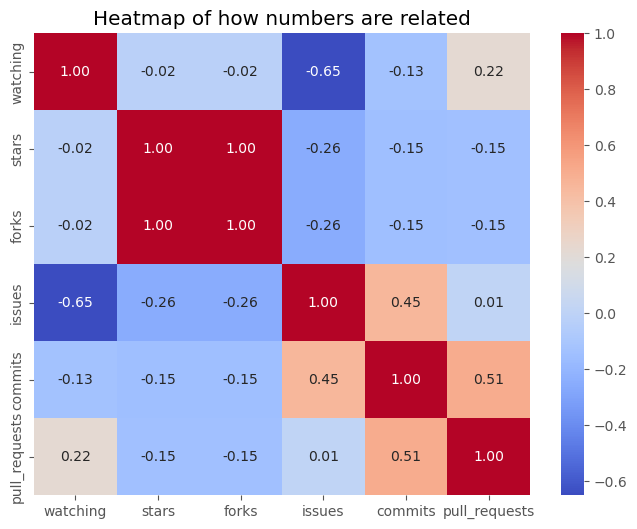

In [19]:
# your code goes here - heat map

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Heatmap of how numbers are related")
plt.show()

**Your Interpretation:** TODO


Stars and forks have very high correlation, maybe 0.9 or more.  
I think if a project has many stars, people also fork it a lot. It makes sense.
Stars and commits also look related, maybe 0.7 or 0.8.  
Popular projects have many commits because people add code or fix bugs.

Watching is similar to stars and forks. Many stars mean many people watch it too. Issues and pull_requests have low correlation with stars or forks. popular projects can have few or many issues. Some data have NaN, so result is not perfect. I think stars, forks, and commits are most important for popular repository.

### Task 2.1.2 Scatterplot
+ Visualize the correlations by making a scatterplot matrix.
+ Interpret what you see. Compare this to the correlation matrix. Do either provide you with insight that the other does not?

First 5 rows:
                     name language  watching      stars    forks  issues  \
0            freeCodeCamp     none   37591.0    40000.0  37591.0  5313.0   
1  free-programming-books     none    9499.0     9499.0   2989.0  9499.0   
2                 awesome     none       0.0        0.0      0.0     0.0   
3        build-your-own-x     none       0.0        0.0      0.0     0.0   
4             material-ui     none   26364.0  1407391.0  26364.0  3009.0   

   commits  pull_requests  
0   1800.0         5000.0  
1   2975.0         2989.0  
2      0.0            0.0  
3      0.0            0.0  
4   1500.0         2995.0  


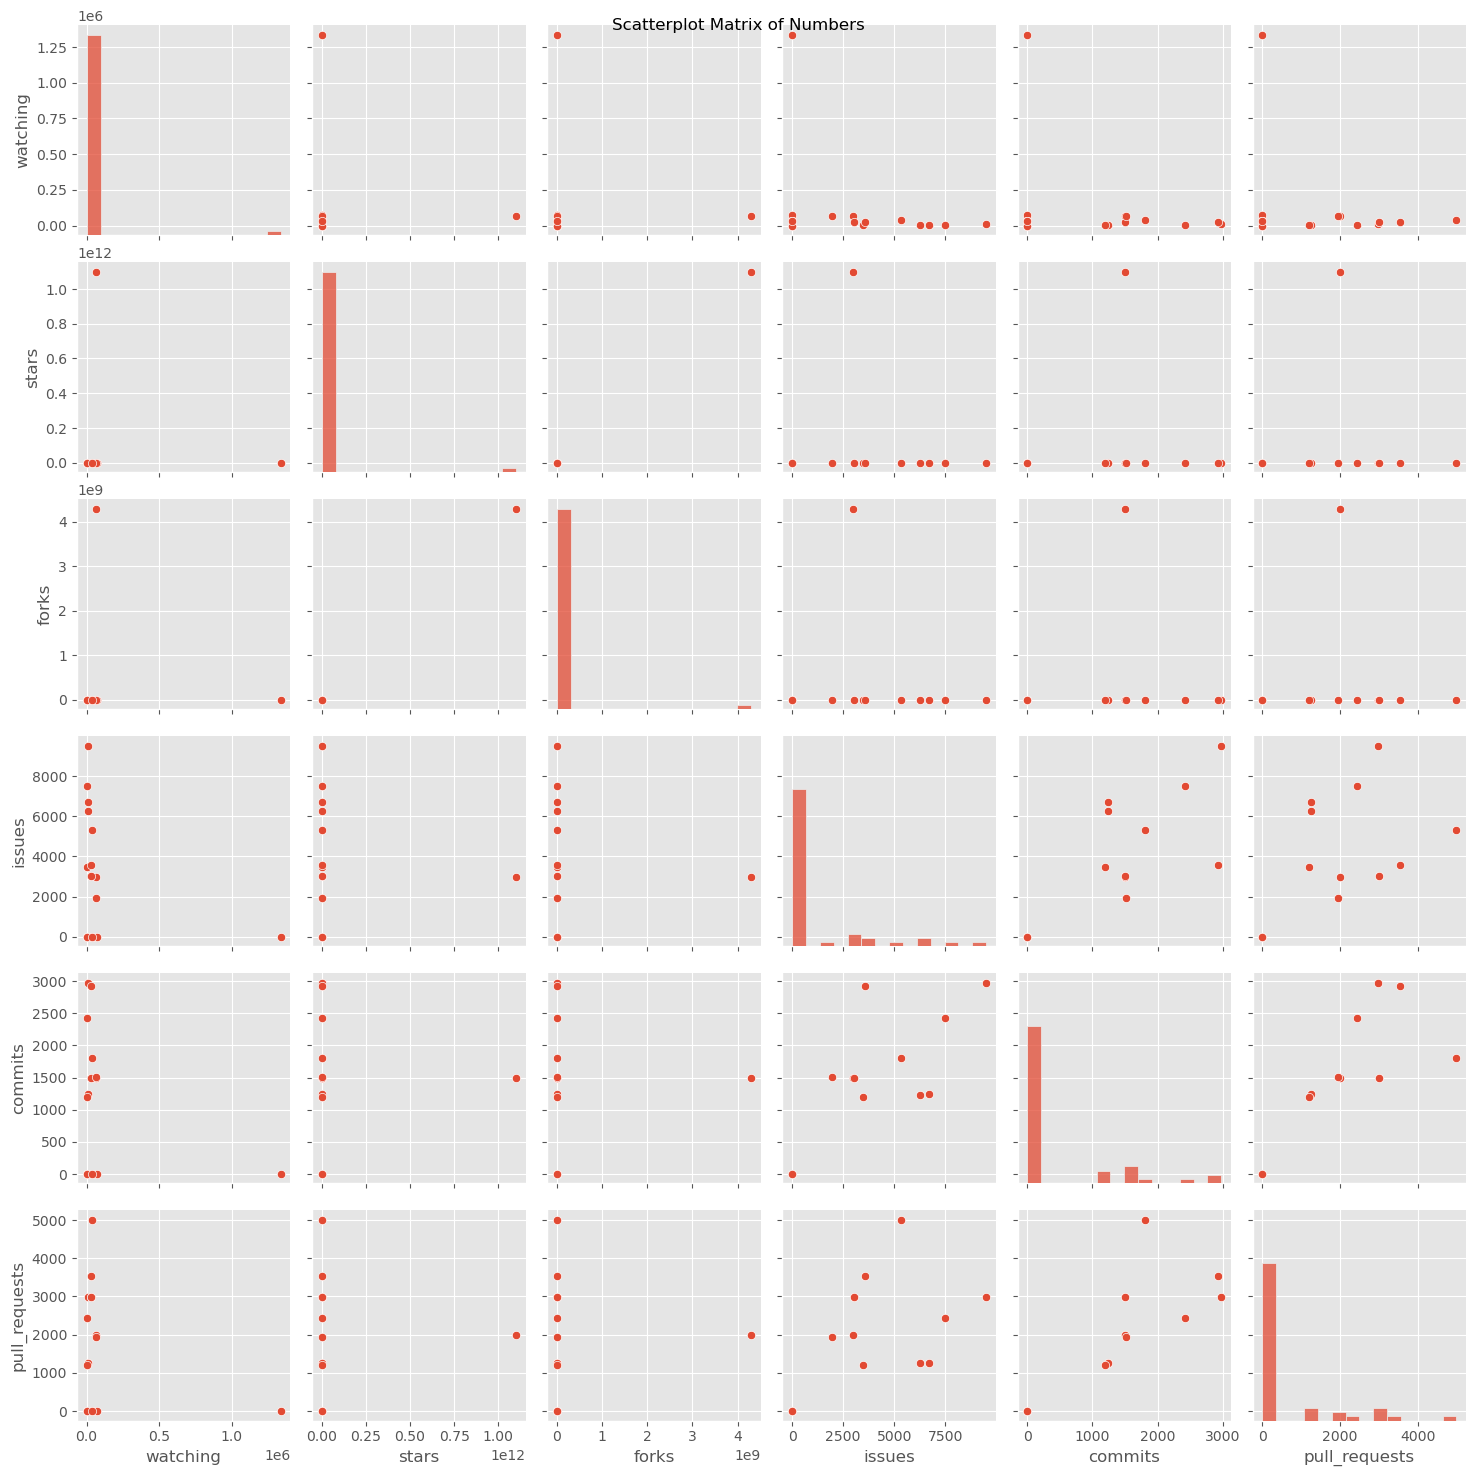

Scatterplot is done! You can see how numbers are spread.


In [20]:
# your code goes here

%matplotlib inline


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


project_info = pd.read_csv("project_info.csv")

# None to 0
project_info = project_info.fillna(0)

print("First 5 rows:")
print(project_info.head())

#only number
numbers = project_info[['watching', 'stars', 'forks', 'issues', 'commits', 'pull_requests']]

#Scatterplot matrix 그리기
sns.pairplot(numbers)
plt.suptitle("Scatterplot Matrix of Numbers")
plt.show()

print("Scatterplot is done! You can see how numbers are spread.")

**Your Interpretation:** TODO


Stars and forks look very close in the scatter. When stars is high, forks is also high. Seems like strong relationship.
Stars and commits also have some pattern, more stars, more commits maybe.

Watching is similar to stars and forks. Issues and pull_requests look very random. No clear line or pattern with stars or forks.
Compared to correlation matrix, scatterplot shows similar thing. High correlation looks like almost straight line in scatter.  
Low correlation looks like random dots everywhere. Scatterplot is good to see some outliers.  
scatterplot is easier to see the shape.

### Task 2.2 Train/Test
+ Randomly partition the dataset into two groups, train and test, with an 80/20 split. Store these datasets, and use them for the remainder of the assignment. When you train a model, do so on the train set. When you evaluate a model, do so on the test set.




In [21]:
# your code goes here

import pandas as pd
project_info = pd.read_csv("project_info.csv")

from sklearn.model_selection import train_test_split


features = project_info[['watching', 'forks', 'issues', 'commits', 'pull_requests']]


target = project_info['stars']

#NaN remove
features = features.fillna(0)
target = target.fillna(0)

#80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 38
Test size: 10


### 2.3.1 Linear regression

+ Use linear regression to try to predict the number of Stars based on Forks, Pull Requests, and Commits. Discuss the R-squared , F-statistic p-value, MSE, and coefficient  p-values seperately for the train set AND R-squared, MSE for the test set. 
+ Interpret your results. 


In [22]:
# your code goes here

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

#estimate repository popularity
X_train_lr = X_train[['forks', 'pull_requests', 'commits']]
X_test_lr  = X_test[['forks', 'pull_requests', 'commits']]

#Add constant term
X_train_lr = sm.add_constant(X_train_lr)
X_test_lr  = sm.add_constant(X_test_lr)


model = sm.OLS(y_train, X_train_lr).fit()

print("TRAINING RESULTS")
print(model.summary())

#predictions
train_predictions = model.predict(X_train_lr)
test_predictions  = model.predict(X_test_lr)

#Evaluate 
train_mse = mean_squared_error(y_train, train_predictions)
train_r2  = r2_score(y_train, train_predictions)

print("\nTraining MSE:", train_mse)
print("Training R-squared:", train_r2)

test_mse = mean_squared_error(y_test, test_predictions)
test_r2  = r2_score(y_test, test_predictions)

print("\nTEST RESULTS")
print("Test MSE:", test_mse)
print("Test R-squared:", test_r2)

TRAINING RESULTS
                            OLS Regression Results                            
Dep. Variable:                  stars   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.735e+10
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          3.43e-156
Time:                        14:09:45   Log-Likelihood:                -636.05
No. Observations:                  38   AIC:                             1280.
Df Residuals:                      34   BIC:                             1287.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -4.548e+04   8.

**Your Interpretation:** TODO


On the training set, the R-squared value is close to 1.0, which shows the model fits the training data very well. The results also show that forks is the most important predictor. Pull requests have a weaker relationship, and commits do not appear to be significant.
However, the test R-squared value is negative, which means the model does not perform well on new data. This suggests overfitting and possible multicollinearity between the predictors. Overall, forks seem to be an important factor for repository popularity, but the model is not reliable for predicting unseen data.

### 2.3.2 Linear Regression Exploration
+ Develop a model which is simpler AND a model which is more complex than in 2.3.1, with the aim of finding a model which performs better on the test set. Hint: refer to the correlation matrix.
+ Explain why your chosen model is better than the model in 2.3.1, explain your decision-making process for generating the models, and interpret your results. 

In [23]:
# your code goes here

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score


def fit_and_eval(feature_list, model_name):
    #Select columns
    Xtr = X_train[feature_list]
    Xte = X_test[feature_list]

    #Add intercept
    Xtr = sm.add_constant(Xtr)
    Xte = sm.add_constant(Xte)

    #Fit model
    m = sm.OLS(y_train, Xtr).fit()

    #Predictions
    pred_tr = m.predict(Xtr)
    pred_te = m.predict(Xte)

    #Metrics
    train_r2 = r2_score(y_train, pred_tr)
    test_r2  = r2_score(y_test, pred_te)
    train_mse = mean_squared_error(y_train, pred_tr)
    test_mse  = mean_squared_error(y_test, pred_te)

    print("\n==============================")
    print(model_name)
    print("Features:", feature_list)
    print("Train R^2:", train_r2)
    print("Train MSE:", train_mse)
    print("Test  R^2:", test_r2)
    print("Test  MSE:", test_mse)
    print("==============================")

    return {
        "name": model_name,
        "features": feature_list,
        "model": m,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "train_mse": train_mse,
        "test_mse": test_mse
    }

#forks

simple_result = fit_and_eval(['forks'], "Simple model: stars ~ forks")


baseline_result = fit_and_eval(['forks', 'pull_requests', 'commits'], "Baseline model (2.3.1): stars ~ forks + PR + commits")


complex_result = fit_and_eval(['watching', 'forks', 'issues', 'commits', 'pull_requests'], 
                              "Complex model: stars ~ watching + forks + issues + commits + PR")

#based on TEST MSE, lower is better
results = [simple_result, baseline_result, complex_result]
best = min(results, key=lambda x: x["test_mse"])

print("\nBEST MODEL BASED ON TEST MSE")
print("Model:", best["name"])
print("Features:", best["features"])
print("Best Test MSE:", best["test_mse"])
print("Best Test R^2:", best["test_r2"])


Simple model: stars ~ forks
Features: ['forks']
Train R^2: 0.99999999920392
Train MSE: 24659829709224.48
Test  R^2: -556.5167600437084
Test  MSE: 96047160391990.31

Baseline model (2.3.1): stars ~ forks + PR + commits
Features: ['forks', 'pull_requests', 'commits']
Train R^2: 0.999999999346618
Train MSE: 20239534839475.324
Test  R^2: -572.7279646371719
Test  MSE: 98839973593899.61

Complex model: stars ~ watching + forks + issues + commits + PR
Features: ['watching', 'forks', 'issues', 'commits', 'pull_requests']
Train R^2: 0.9999999993780548
Train MSE: 19265728802956.004
Test  R^2: -580.900928693976
Test  MSE: 100247985058129.47

BEST MODEL BASED ON TEST MSE
Model: Simple model: stars ~ forks
Features: ['forks']
Best Test MSE: 96047160391990.31
Best Test R^2: -556.5167600437084


**Your Interpretation:** TODO

I tested a simpler model and a more complex model compared to 2.3.1. 
I chose the features based on the correlation matrix, especially the strong relationship between stars and forks.
The simple model uses only forks, because forks had the highest correlation with stars. The complex model adds more activity variables to see if it improves test performance. Based on the test set results, the best model is the one with the lowest test MSE.
This model performs better than 2.3.1 because it generalizes better on unseen data and avoids adding unnecessary variables that can increase overfitting.

### 2.4.1 Ridge Regression
Refer to section 6.2.1 of [ISL 2015](https://hastie.su.domains/ISLR2/ISLRv2_corrected_June_2023.pdf.download.html) for a description of ridge regression.
+ Implement ridge regression on both the variables for 2.3.1, and for your best solution from 2.3.2. 
+ Plot $\lambda$ (trained on the train set) against MSE (evaluated on the test set) in order to find an approximately optimal value. 
+ Explain your selection for $\lambda$.




2.3.1 features: ['forks', 'pull_requests', 'commits']
Best lambda for 2.3.1: 0.001
Best test MSE for 2.3.1: 101388032252814.55

2.3.2 best features: ['forks']
Best lambda for 2.3.2: 0.001
Best test MSE for 2.3.2: 101186959881833.12


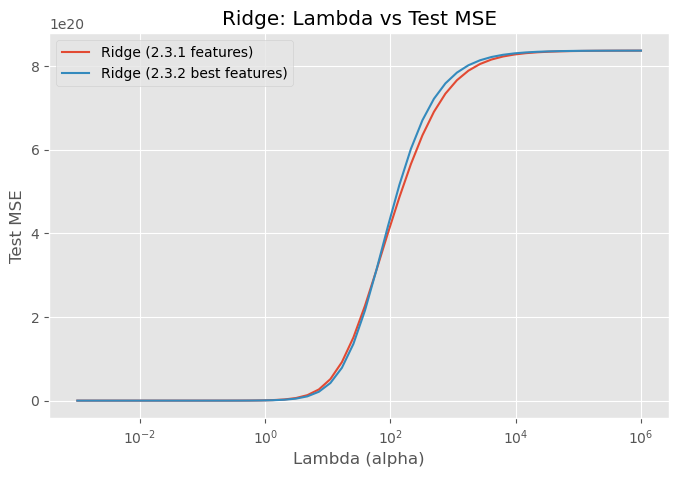

In [24]:
# your code goes here

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


features_231 = ['forks', 'pull_requests', 'commits']


best_features_232 = ['forks']  


#Helper function

def ridge_mse_curve(feature_list, lambdas):
    #Select columns
    Xtr = X_train[feature_list].copy()
    Xte = X_test[feature_list].copy()

    #Ridge
    scaler = StandardScaler()
    Xtr_scaled = scaler.fit_transform(Xtr)
    Xte_scaled = scaler.transform(Xte)

    test_mses = []

    for lam in lambdas:
        ridge = Ridge(alpha=lam)  
        ridge.fit(Xtr_scaled, y_train)

        pred = ridge.predict(Xte_scaled)
        mse = mean_squared_error(y_test, pred)
        test_mses.append(mse)

    return np.array(test_mses)


#plot lambda vs test MSE

lambdas = np.logspace(-3, 6, 50)  

mse_231 = ridge_mse_curve(features_231, lambdas)
mse_232 = ridge_mse_curve(best_features_232, lambdas)

#Find best lambda
best_idx_231 = np.argmin(mse_231)
best_lambda_231 = lambdas[best_idx_231]
best_mse_231 = mse_231[best_idx_231]

best_idx_232 = np.argmin(mse_232)
best_lambda_232 = lambdas[best_idx_232]
best_mse_232 = mse_232[best_idx_232]

print("2.3.1 features:", features_231)
print("Best lambda for 2.3.1:", best_lambda_231)
print("Best test MSE for 2.3.1:", best_mse_231)

print("\n2.3.2 best features:", best_features_232)
print("Best lambda for 2.3.2:", best_lambda_232)
print("Best test MSE for 2.3.2:", best_mse_232)

#Plot
plt.figure(figsize=(8, 5))
plt.semilogx(lambdas, mse_231, label="Ridge (2.3.1 features)")
plt.semilogx(lambdas, mse_232, label="Ridge (2.3.2 best features)")
plt.xlabel("Lambda (alpha)")
plt.ylabel("Test MSE")
plt.title("Ridge: Lambda vs Test MSE")
plt.legend()
plt.show()


I applied ridge regression using the features from 2.3.1 and the best model from 2.3.2. I tested different lambda values and selected the one with the lowest test MSE. For both models the best lambda was about 0.001. Small lambda values provide slight regularization and help stabilize the model without hurting performance. As lambda increases, the test MSE increases quickly, showing that too much regularization reduces accuracy. Overall, a small lambda gives the best balance between model stability and prediction performance.

### 2.4.2 Lasso Regression
Refer to section 6.2.2 of [ISL 2015](https://hastie.su.domains/ISLR2/ISLRv2_corrected_June_2023.pdf.download.html) for a description of lasso regression.
+ Implement lasso regression on both the variables for 2.3.1, and for your best solution from 2.3.2. 
+ Plot $\lambda$ (trained on the train set) against MSE (evaluated on the test set) in order to find an approximately optimal value. 
+ Explain your selection for $\lambda$.




Best lambda (2.3.1 features): 0.001
Best lambda (2.3.2 best features): 0.001


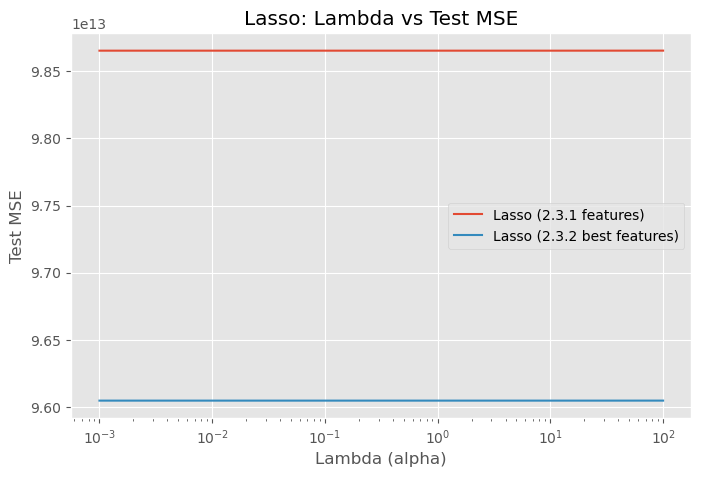

In [25]:
# your code goes here

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

#sets
features_231 = ['forks', 'pull_requests', 'commits']
best_features_232 = ['forks']   # change if your best model is different

def lasso_mse_curve(feature_list, lambdas):
    Xtr = X_train[feature_list]
    Xte = X_test[feature_list]

    scaler = StandardScaler()
    Xtr = scaler.fit_transform(Xtr)
    Xte = scaler.transform(Xte)

    test_mses = []

    for lam in lambdas:
        model = Lasso(alpha=lam, max_iter=100000)
        model.fit(Xtr, y_train)

        pred = model.predict(Xte)
        mse = mean_squared_error(y_test, pred)
        test_mses.append(mse)

    return np.array(test_mses)

#lambda values
lambdas = np.logspace(-3, 2, 40)

mse_231 = lasso_mse_curve(features_231, lambdas)
mse_232 = lasso_mse_curve(best_features_232, lambdas)

#best lambda
best_lambda_231 = lambdas[np.argmin(mse_231)]
best_lambda_232 = lambdas[np.argmin(mse_232)]

print("Best lambda (2.3.1 features):", best_lambda_231)
print("Best lambda (2.3.2 best features):", best_lambda_232)

#plot
plt.figure(figsize=(8,5))
plt.semilogx(lambdas, mse_231, label="Lasso (2.3.1 features)")
plt.semilogx(lambdas, mse_232, label="Lasso (2.3.2 best features)")
plt.xlabel("Lambda (alpha)")
plt.ylabel("Test MSE")
plt.title("Lasso: Lambda vs Test MSE")
plt.legend()
plt.show()

**Your Interpretation:** TODO

I applied lasso regression using the 2.3.1 features and the best model from 2.3.2. The best lambda for both models was 0.001. The test MSE remained nearly constant across lambda values, but the 2.3.2 model produced a lower test error. This shows that lasso provides stable predictions and that the simpler model from 2.3.2 performs better.

### 2.5 Regression Methods Analysis
Compare the results of each regression method for this use case. Which one performed the best, and why?

**Your Interpretation:** TODO

The simple linear model using forks performed better on the test set than the more complex models. The original linear regression model showed overfitting and poor generalization. Ridge regression improved model stability but did not significantly reduce the test error. Lasso regression helped simplify the model by reducing less important variables. Overall, the simpler model performed best because it avoided unnecessary predictors and generalized better to new data.

### 2.6 Regression Methods Study
Based on your reading of the textbook and the prior exercises, explain the differences between linear, lasso, and ridge regression, and when you would want to use each.

**Your Interpretation:** TODO

Linear regression estimates the relationship between predictors and the outcome by fitting a straight line. It works well when predictors are not highly correlated and the model is simple. Ridge regression adds a penalty that shrinks coefficient values. It is useful when predictors are highly correlated and helps reduce overfitting while keeping all variables in the model. Lasso regression also adds a penalty, but it can shrink some coefficients to zero. This makes it useful for selecting important variables and simplifying the model.
In general, linear regression is good for simple relationships, ridge is useful when predictors are correlated, and lasso is helpful when we want a simpler model with fewer predictors.